In [134]:
import sys, os
import statsmodels as ss
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import warnings
os.chdir(r'C:\Users\jrdiy\OneDrive\Рабочий стол\vs_code\Time-series\smoothing\data1')
from colorsetup import colors, palette
sns.set_palette(palette)

warnings.filterwarnings("ignore")



In [135]:
np.random.seed(42)

time=np.arange(100)
stationary = np.random.normal(loc = 0, scale = 1.0, size = len(time))

In [136]:
def run_sequence_plot(x, y, title, xlabel ="time", ylabel="series"):
    plt.plot(x, y, 'k-')
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(alpha=0.3)



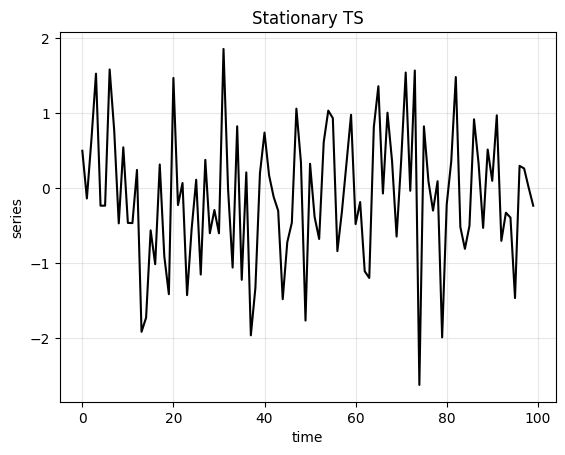

In [137]:
run_sequence_plot(time, stationary,
                  title="Stationary TS")

In [138]:
stationary_time_series_avg = np.mean(stationary)
sts_avg = np.full(shape=len(time), fill_value=stationary_time_series_avg, dtype='float')


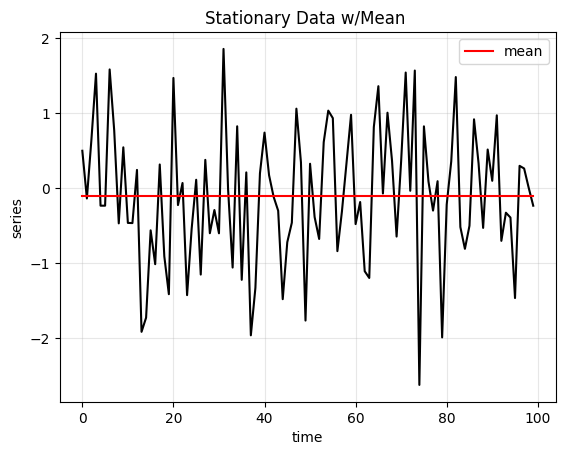

In [139]:
run_sequence_plot(time, stationary, 
                  title="Stationary Data w/Mean ")
plt.plot(time, sts_avg, 'r', label="mean")
plt.legend()

In [140]:
# plt.plot(time, stationary,  'g', label="Fluctuation")   # or "Stationary"
# plt.plot(time, sts_avg, 'r', label="Mean")

# plt.title("Stationary Data w/Mean")
# plt.legend()
# plt.show()


In [141]:
def mse(observations, estimates):
    assert type(observations)== type(np.array([]))
    assert type(estimates)==type(np.array([]))
    assert len(observations) == len(estimates)

    difference = observations -estimates
    sq_diff = difference**2
    mse = sum(sq_diff)

    return mse




In [142]:
ones =mse(np.array([0,1,2,4]), np.array([1,1,1,1]))
print(ones)

11


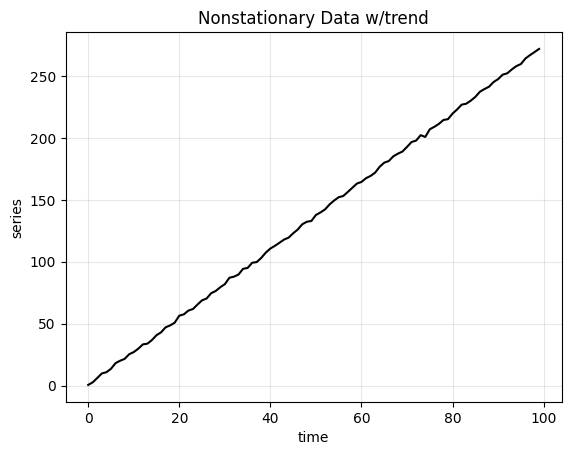

In [143]:
trend = (time *2.75) + stationary
run_sequence_plot(time, trend, title="Nonstationary Data w/trend")

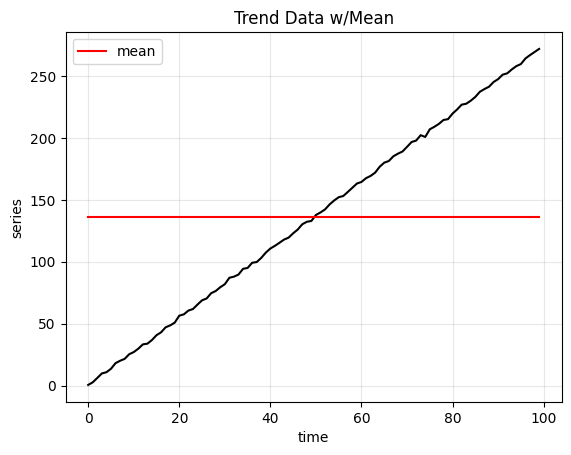

In [144]:
trend_time_series_avg = np.mean(trend)

trend_avg = np.full(shape=len(time), fill_value=trend_time_series_avg, dtype='float')

run_sequence_plot(time, trend, 
                  title="Trend Data w/Mean")
plt.plot(time, trend_avg, 'r', label ="mean")
plt.legend()


In [145]:
#New Data From here, Not related to the above data
dummy_data = np.arange(10)
dummy_avg = np.mean(dummy_data)
dummy_avg_array = np.full(shape=len(dummy_data), fill_value=dummy_avg, dtype='float')

dummy_simple_average_mse = mse(dummy_data,dummy_avg_array)
dummy_smoothed_average_mse = mse(dummy_data[1:-1], np.arange(1,9))

print("MSE")
print("-" *12)
print("Simple: ", dummy_simple_average_mse)
print("Smoothed:", dummy_smoothed_average_mse)



MSE
------------
Simple:  82.5
Smoothed: 0


In [146]:
def moving_average(observations, window=3, forecast=False):
    cumulative_sum = np.cumsum(observations, dtype=float)
    cumulative_sum[window:] = cumulative_sum[window:] - cumulative_sum[:-window]
    if forecast:
        return np.insert(cumulative_sum[window - 1:] / window, 0, np.zeros(3))
    else:
        return cumulative_sum[window - 1:] / window

In [147]:
smoothed_trend = moving_average(trend, window=3, forecast=False)

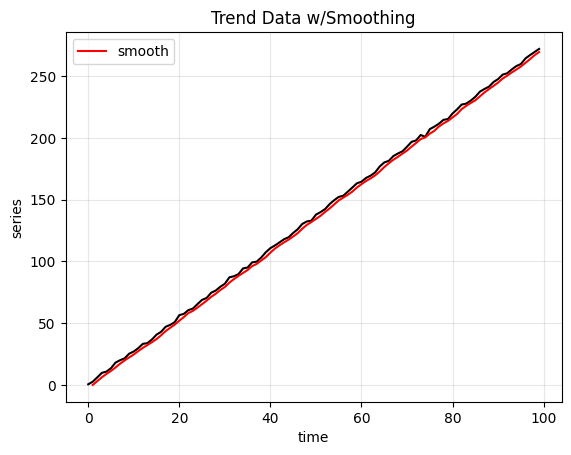

In [148]:
run_sequence_plot(time, trend,
                  title="Trend Data w/Smoothing")
plt.plot(time[1:], np.insert(smoothed_trend,0,0), 'r', label="smooth")
plt.legend()

In [149]:
seasonality = 10+np.sin(time)*10
smoothed_seasonality = moving_average(seasonality, window=3, forecast=False)

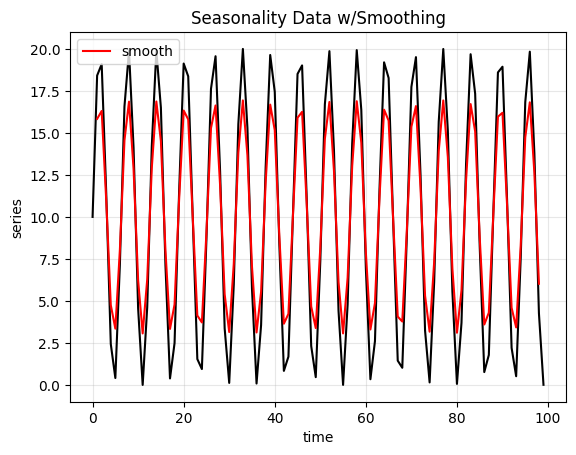

In [150]:
run_sequence_plot(time, seasonality, 
                  title="Seasonality Data w/Smoothing")
plt.plot(time[1:-1],smoothed_seasonality, 'r', label="smooth")
plt.legend(loc ='upper left')

In [151]:
trend_seasonality = trend +seasonality +stationary
smoothed_trend_seasonality = moving_average(trend_seasonality, window=3,forecast=False)

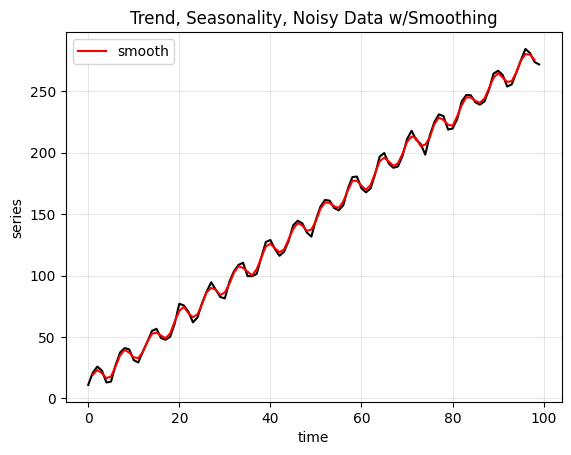

In [152]:
run_sequence_plot(time, trend_seasonality,
                  title="Trend, Seasonality, Noisy Data w/Smoothing")
plt.plot(time[1:-1], smoothed_trend_seasonality, 'r', label= "smooth")
plt.legend(loc='upper left')

In [153]:
values = np.array([1,2,4,8,16,32,64])
ma_smoothed_vals = moving_average(values, window=3, forecast=True)


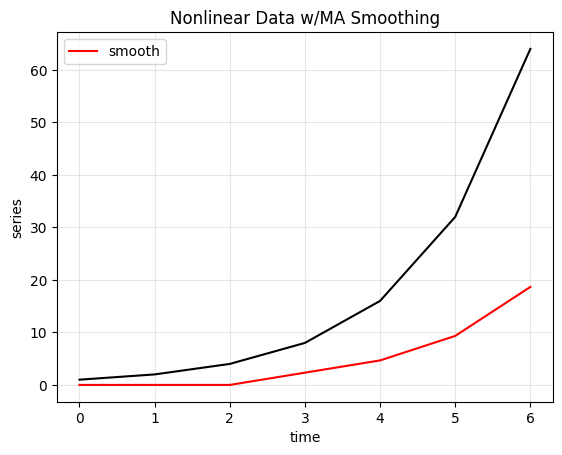

In [154]:
t = np.arange(len(values))
run_sequence_plot(t, values,
                  title="Nonlinear Data w/MA Smoothing")
plt.plot(t, ma_smoothed_vals[:-1], 'r', label="smooth")
plt.legend(loc='upper left');

In [155]:
def ewma(observations, forecast=True):
    weights = np.array([0.160,0.294,0.543])
    output = np.zeros_like(observations, dtype='float')
    for i, _ in enumerate(observations):
        if (i==0) or (i==1) or (i==len(observations)- 1):
            pass
        else:
            output[i] = np.dot(observations[i-2:i+1], weights)
            #(i-2+1) * weight
    if forecast:    
        return np.insert(output, 0,0)
    else:
        return output
    
# Example with observations = [1,2,3,4,5,6,7,8,9]:
#
# i=2 uses [1,2,3]:
#   output[2] = 0.160*1 + 0.294*2 + 0.543*3
#            = 0.160   + 0.588   + 1.629
#            = 2.377
#
# i=3 uses [2,3,4]:
#   output[3] = 0.160*2 + 0.294*3 + 0.543*4
#            = 0.320   + 0.882   + 2.172
#            = 3.374
#
# i=4 uses [3,4,5]:
#   output[4] = 0.160*3 + 0.294*4 + 0.543*5
#            = 0.480   + 1.176   + 2.715
#            = 4.371
#
# ...and so on.

In [156]:
ewma_smoothed_vals = ewma(values, forecast=True)


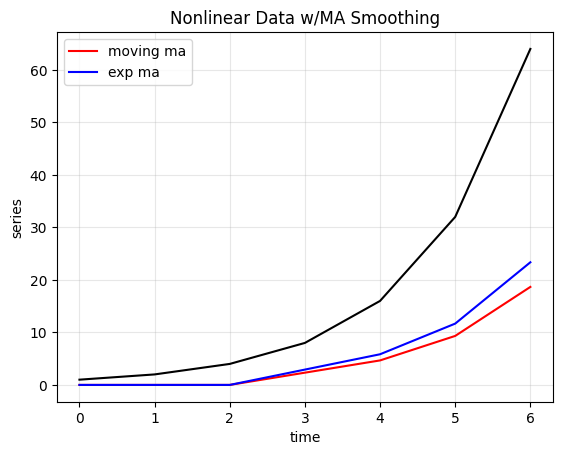

In [157]:
run_sequence_plot(t, values,
                  title="Nonlinear Data w/MA Smoothing")
plt.plot(t, ma_smoothed_vals[:-1], 'r', label="moving ma")
plt.plot(t, ewma_smoothed_vals[:-1], 'b', label="exp ma")
plt.legend(loc='upper left');

In [158]:
train = trend_seasonality[:-5]              
test = trend_seasonality[-5:]                 


In [159]:
trend_seasonal_avg = np.mean(trend_seasonality)

simple_avg_preds = np.full(shape=len(test), fill_value=trend_seasonal_avg, dtype='float')

simple_mse = mse(test, simple_avg_preds)

print("Predictions: ", simple_avg_preds)
print("MSE:", simple_mse)


Predictions:  [145.95522643 145.95522643 145.95522643 145.95522643 145.95522643]
MSE: 86295.31932923789


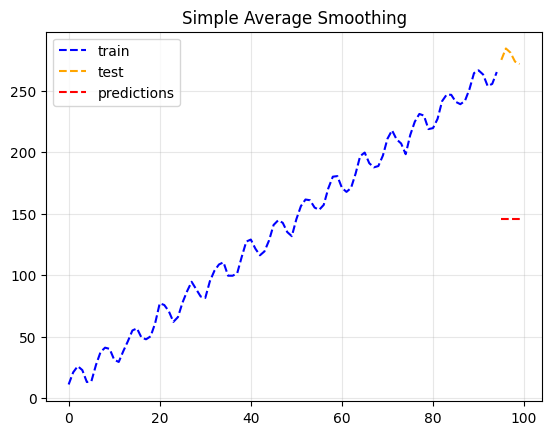

In [160]:
plt.plot(time[:-5], train, 'b--', label="train")
plt.plot(time[-5:], test, color='orange', linestyle="--", label="test")
plt.plot(time[-5:], simple_avg_preds, 'r--', label="predictions")
plt.legend(loc='upper left')
plt.title("Simple Average Smoothing")
plt.grid(alpha=0.3)

In [161]:
from statsmodels.tsa.api import SimpleExpSmoothing

single = SimpleExpSmoothing(train).fit(optimized=True)
single_preds = single.forecast(len(test))
single_mse = mse(test, single_preds)
print("Predictions: ", single_preds)
print("MSE :", single_mse)

Predictions:  [265.2632637 265.2632637 265.2632637 265.2632637 265.2632637]
MSE : 830.001033618639


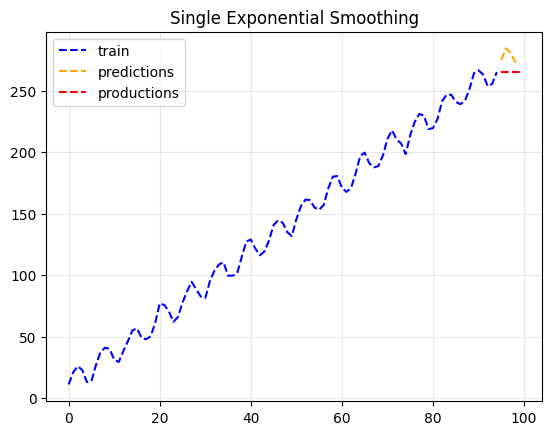

In [162]:
plt.plot(time[:-5], train, 'b--', label="train")
plt.plot(time[-5:], test, color='orange', linestyle='--', label='predictions')
plt.plot(time[-5:], single_preds, 'r--', label="productions")
plt.legend(loc='upper left')
plt.title("Single Exponential Smoothing")
plt.grid(alpha=0.3)

In [163]:
from statsmodels.tsa.api import Holt

double = Holt(train).fit(optimized=True)
double_preds = double.forecast(len(test))
double_mse = mse(test, double_preds)
print("Predictions:", double_preds)
print("MSE:", double_mse)

Predictions: [267.83038676 270.39750979 272.96463283 275.53175586 278.09887889]
MSE: 359.08301336437063


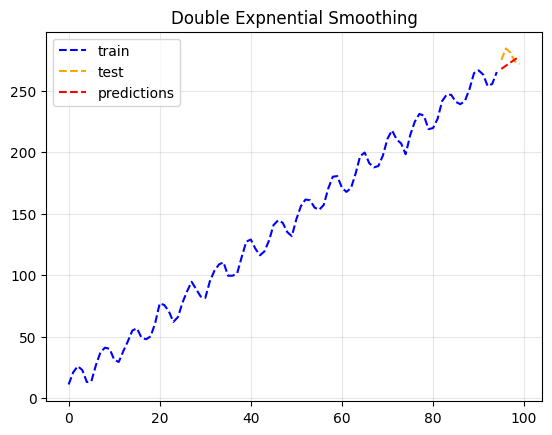

In [164]:
plt.plot(time[:-5], train, 'b--', label="train")
plt.plot(time[-5:],test, color='orange', linestyle='--', label="test")
plt.plot(time[-5:], double_preds, 'r--', label="predictions")
plt.legend(loc='upper left')
plt.title("Double Expnential Smoothing")
plt.grid(alpha=0.3)

In [165]:
from statsmodels.tsa.api import ExponentialSmoothing

triple = ExponentialSmoothing(train,
                              trend="additive",
                              seasonal="additive",
                              seasonal_periods=13).fit(optimized=True)
triple_preds = triple.forecast(len(test))
triple_mse = mse(test, triple_preds)
print("Predictions: ", triple_preds)
print("MSE: ", triple_mse)

Predictions:  [277.27543894 282.5844672  282.40227912 276.67309291 274.78358302]
MSE:  27.032381713884654


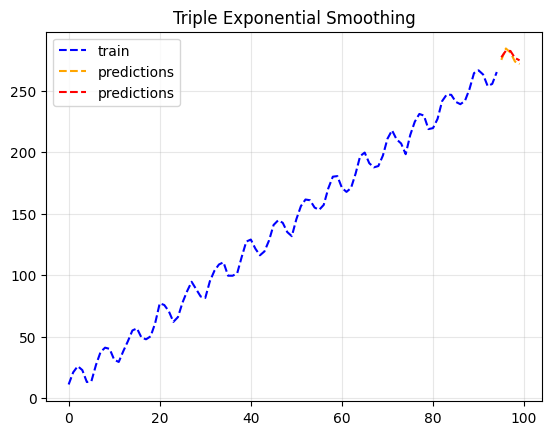

In [166]:
plt.plot(time[:-5], train, 'b--', label="train")
plt.plot(time[-5:],test, color='orange', linestyle='--', label="predictions")
plt.plot(time[-5:], triple_preds, 'r--', label="predictions")
plt.legend(loc='upper left')
plt.title("Triple Exponential Smoothing")
plt.grid(alpha=0.3)

In [167]:
data_dict = {'MSE':[simple_mse, single_mse, double_mse, triple_mse]}
df = pd.DataFrame(data_dict, index=['simple', 'single', 'double','triple' ])
print(df)

                 MSE
simple  86295.319329
single    830.001034
double    359.083013
triple     27.032382


In [168]:
path_to_file = r"C:\Users\jrdiy\OneDrive\Рабочий стол\vs_code\Time-series\smoothing\\"
smooth_1 = np.load(path_to_file + "smooth_1.npy")
smooth_2 = np.load(path_to_file + "smooth_2.npy")


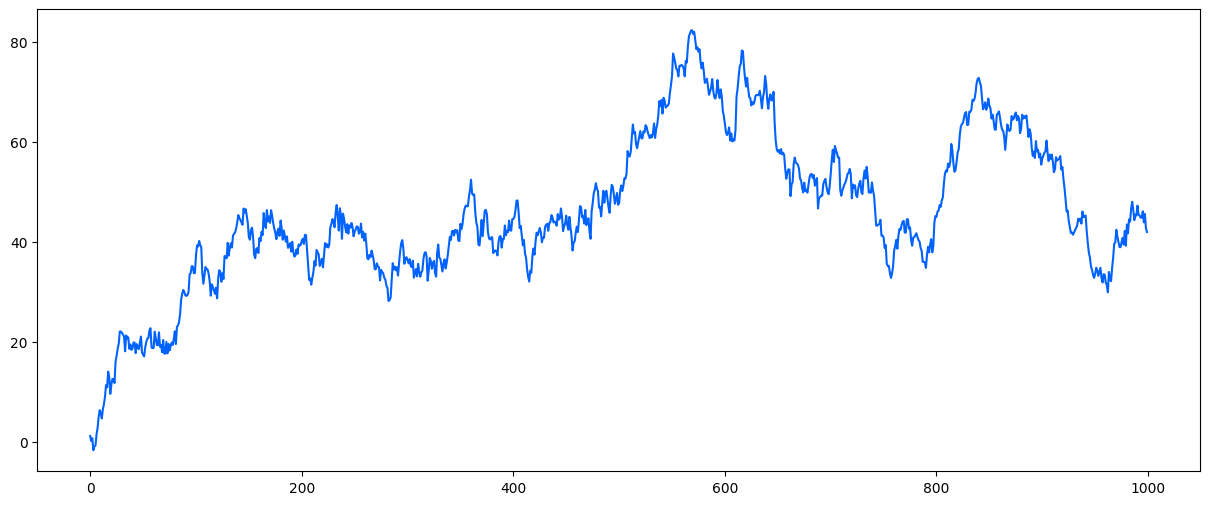

In [169]:
plt.figure(figsize=(15,6))
plt.plot(smooth_2)

In [170]:
mytime = np.arange(len(smooth_1))


In [171]:
test_size =100

train_1 = smooth_1[:-test_size]
train_2 = smooth_2[:-test_size]

test_1 = smooth_1[-test_size:]
test_2 = smooth_2[-test_size:]



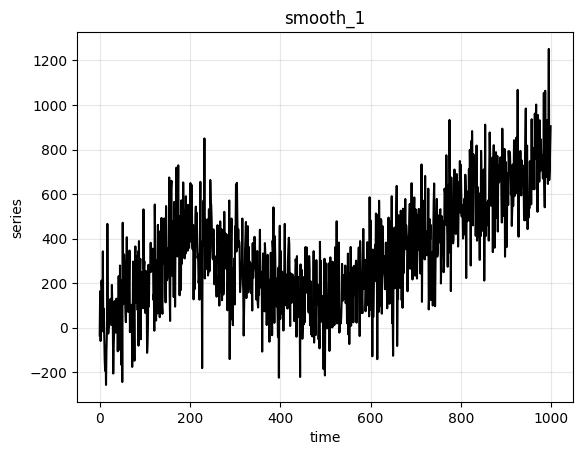

In [172]:
run_sequence_plot(mytime, smooth_1, title='smooth_1')

Text(0.5, 1.0, 'smooth_2')

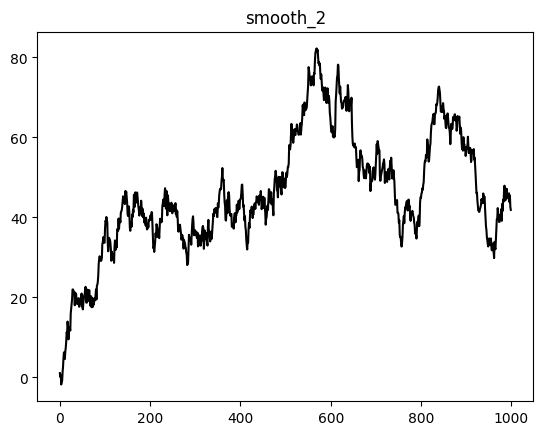

In [173]:
plt.plot(smooth_2, 'k')
plt.title("smooth_2")

In [174]:
from statsmodels.tsa.api import ExponentialSmoothing

model_1 = ExponentialSmoothing(train_1,damped=True,
                              trend="additive",
                              seasonal=None,
                              seasonal_periods=None).fit(optimized=True)

model_2 = ExponentialSmoothing(train_2,
                              trend=None,
                              seasonal=None,
                              seasonal_periods=None).fit(optimized=True)

preds_1 = model_1.forecast(len(test_2))
preds_2 = model_2.forecast(len(test_2))

In [175]:
((test_1-preds_1)**2).sum()/len(test_1)


np.float64(27505.512449100985)

In [176]:
mse_1 = mse(test_1, preds_1)
mse_2 = mse(test_2, preds_2)
print("MSE for smooth_1: {:.7}".format(mse_1))
print("MSE for smooth_2: {:.7}".format(mse_2))

MSE for smooth_1: 2.750551e+06
MSE for smooth_2: 19678.4


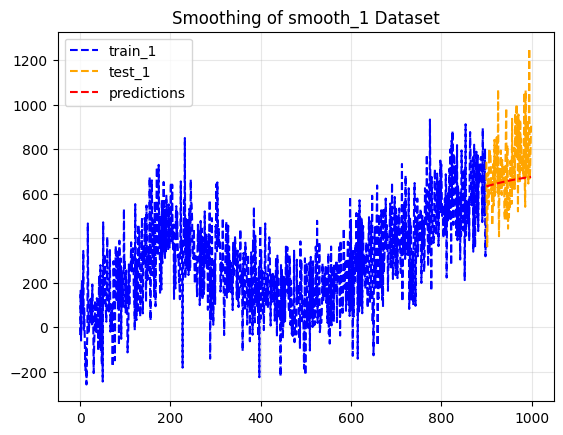

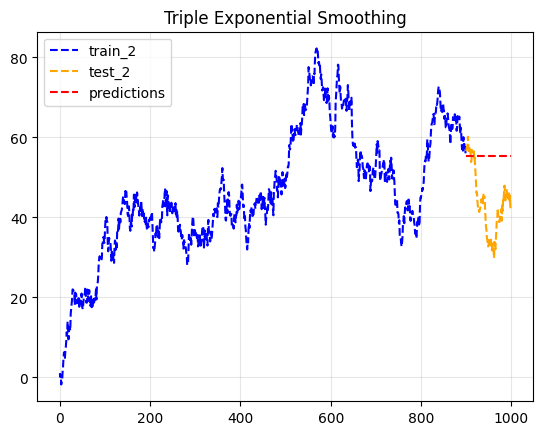

In [177]:
plt.plot(mytime[:-test_size], train_1, 'b--', label="train_1")
plt.plot(mytime[-test_size:], test_1, color='orange', linestyle="--", label="test_1")
plt.plot(mytime[-test_size:], preds_1, 'r--', label="predictions")
plt.legend(loc='upper left')
plt.title("Smoothing of smooth_1 Dataset")
plt.grid(alpha=0.3);

plt.show()

plt.plot(mytime[:-test_size], train_2, 'b--', label="train_2")
plt.plot(mytime[-test_size:], test_2, color='orange', linestyle="--", label="test_2")
plt.plot(mytime[-test_size:], preds_2, 'r--', label="predictions")
plt.legend(loc='upper left')
plt.title("Triple Exponential Smoothing")
plt.grid(alpha=0.3);